# 16 Resolution Time ML

This copy notebook focuses on **time-to-resolution inference**.

We do not train a main model for `resolution_bool` here. Whether a case closed is useful metadata, but the modeling question for this stage is the length of resolution time among events with an observed closure.

Important treatment:
- `resolution = NA` means open / unresolved / censored
- unresolved events are summarized as context
- unresolved events are excluded from the regression target because no final resolution time exists

Split rule:
- one classic stratified `75/15/10` train/validation/test split
- stratification uses resolution-time bands plus `mayoral_administration` when feasible
- model selection is a hyperparameter-grid sweep on train/validation; test is untouched final evaluation

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

observed flood events: 34,870
closed with resolution time: 34,542
open / unresolved / censored: 328


,feature_group,expected_features,available_features,mean_non_null_rate,missing_features
0,event_time,8,8,0.998824,0
1,extra,18,18,0.999471,0
2,governance,3,3,1.000000,0
3,hydrometeorology,6,6,0.987104,0
4,infrastructure,4,4,0.500000,0
5,network,9,9,0.444444,0
6,socioeconomic,4,4,0.983589,0
7,spatial_controls,5,5,1.000000,0
8,targets,4,4,0.997648,0
9,terrain_coastal,8,8,0.999986,0


,feature_group,feature,available,dtype,non_null_rate,n_unique
0,event_time,day_of_week,True,Int64,1.000000,7
1,event_time,duration,True,float64,1.000000,7452
2,event_time,end,True,datetime64[us],0.990594,31625
3,event_time,hour,True,Int64,1.000000,24
4,event_time,month,True,Int64,1.000000,12
5,event_time,season,True,string,1.000000,4
6,event_time,start,True,datetime64[us],1.000000,32123
7,event_time,storm_event_id,True,string,1.000000,117
8,extra,catch_basin_nearest_ft,True,float64,1.000000,16985
9,extra,component_size,True,int64,1.000000,52


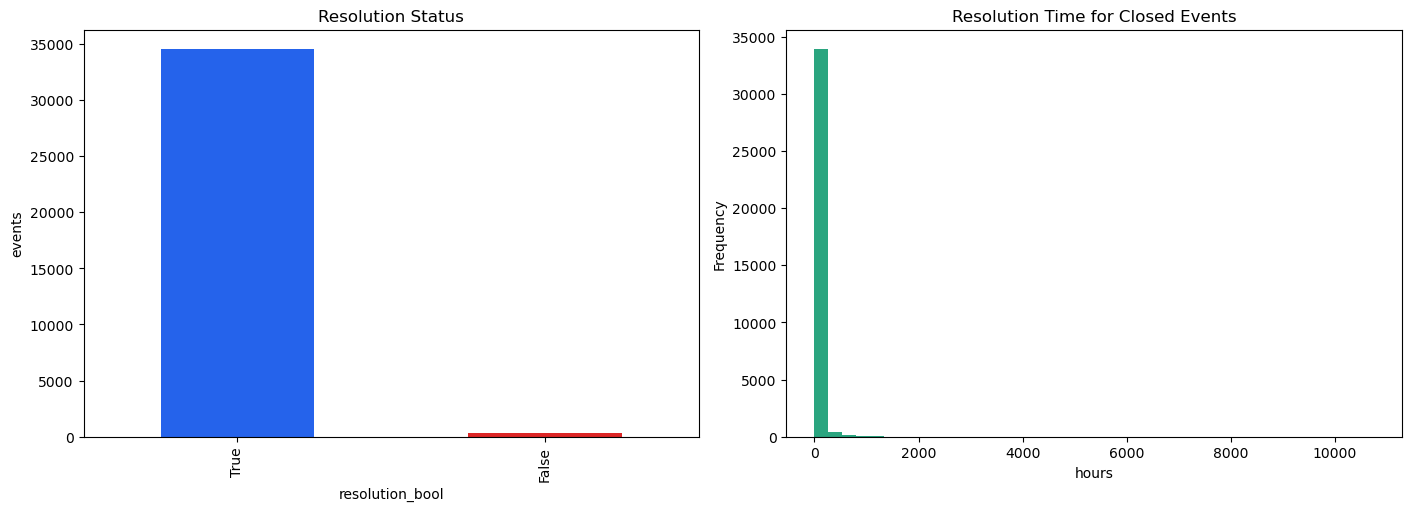

In [2]:
from project_name.modeling_stage import (
    RESOLUTION_BIAS_DIAGNOSTICS_PATH,
    RESOLUTION_FEATURE_IMPORTANCE_PATH,
    RESOLUTION_LEAKAGE_AUDIT_PATH,
    RESOLUTION_PREDICTIONS_PATH,
    RESOLUTION_TIME_RESULTS_PATH,
    compact_modeling_summary,
    feature_catalog,
    load_modeling_frame,
    run_resolution_time_ml,
    summarize_feature_groups,
)

observed = load_modeling_frame(view_name="strict_main", include_geometry=False, observed_only=True)
closed = observed[observed["resolution"].notna()].copy()
open_or_censored = observed[observed["resolution"].isna()].copy()

print(f"observed flood events: {len(observed):,}")
print(f"closed with resolution time: {len(closed):,}")
print(f"open / unresolved / censored: {len(open_or_censored):,}")
display(summarize_feature_groups(observed))
display(feature_catalog(observed).head(40))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
observed["resolution_bool"].astype("boolean").value_counts(dropna=False).plot.bar(ax=axes[0], color=["#2563EB", "#DC2626"])
axes[0].set_title("Resolution Status")
axes[0].set_xlabel("resolution_bool")
axes[0].set_ylabel("events")

pd.to_numeric(closed["resolution"], errors="coerce").plot.hist(ax=axes[1], bins=40, color="#059669", alpha=0.85)
axes[1].set_title("Resolution Time for Closed Events")
axes[1].set_xlabel("hours")
plt.show()

In [3]:
results, predictions, feature_importance = run_resolution_time_ml(observed)

display(compact_modeling_summary(results, ["mae", "rmse", "r2"]).head(30))
display(results.sort_values(["mae", "rmse"], ascending=[True, True], kind="stable").head(30))
display(feature_importance.head(30))

print(f"saved: {RESOLUTION_TIME_RESULTS_PATH}")
print(f"saved: {RESOLUTION_PREDICTIONS_PATH}")
print(f"saved: {RESOLUTION_FEATURE_IMPORTANCE_PATH}")
print(f"saved: {RESOLUTION_BIAS_DIAGNOSTICS_PATH}")
print("incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/resolution_time")

/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/home/map10194/miniconda3/envs/urban-flood-stress/lib/python3.11/site-packages/pandas/core/nanops.py:1672: ConstantInputWarning: An input array is constant;

,task_name,split_strategy,model_name,status,mae,rmse,r2,best_params,notes
0,resolution_time,stratified_75_15_10,ridge,ok,93.574932,3875.126994,-842.642414,"{""model__alpha"": 100.0}",Classic 75/15/10 split. Stratification priorit...
1,resolution_time,stratified_75_15_10,linear_regression,ok,90.864410,3704.926327,-770.162104,{},Classic 75/15/10 split. Stratification priorit...
2,resolution_time,stratified_75_15_10,dummy_regressor,ok,33.568394,135.256612,-0.027788,{},Classic 75/15/10 split. Stratification priorit...
3,resolution_time,stratified_75_15_10,random_forest_regressor,ok,22.337059,88.733612,0.557653,"{""model__max_depth"": null, ""model__max_feature...",Classic 75/15/10 split. Stratification priorit...
4,resolution_time,stratified_75_15_10,gradient_boosting_regressor,ok,19.873659,58.518888,0.807612,"{""model__learning_rate"": 0.03, ""model__max_dep...",Classic 75/15/10 split. Stratification priorit...


,task_name,split_strategy,model_name,status,n_train,n_validation,n_test,n_features,best_params,validation_primary_score,cv_validation_primary_score,cv_train_primary_score,notes,rmse,mae,r2,median_absolute_error,spearman_correlation,pearson_correlation,mape,train_rmse,train_mae,train_r2,train_median_absolute_error,train_spearman_correlation,train_pearson_correlation,train_mape,validation_rmse,validation_mae,validation_r2,validation_median_absolute_error,validation_spearman_correlation,validation_pearson_correlation,validation_mape,test_rmse,test_mae,test_r2,test_median_absolute_error,test_spearman_correlation,test_pearson_correlation,test_mape,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
4,resolution_time,stratified_75_15_10,gradient_boosting_regressor,ok,25906,5181,3455,36,"{""model__learning_rate"": 0.03, ""model__max_dep...",-1.587226e+01,-1.587226e+01,-15.637508,Classic 75/15/10 split. Stratification priorit...,58.518888,19.873659,0.807612,6.183590,-0.003958,-0.025330,NaN,51.043295,15.637508,0.904078,4.915210,-0.011901,2.885471e-03,NaN,4.945855e+01,1.587226e+01,9.685509e-01,4.860700,0.028982,-0.021086,NaN,58.518888,19.873659,0.807612,6.183590,-0.003958,-0.025330,NaN,2.347494e-01,4.001401e+00,True,True
3,resolution_time,stratified_75_15_10,random_forest_regressor,ok,25906,5181,3455,36,"{""model__max_depth"": null, ""model__max_feature...",-1.287247e+01,-1.287247e+01,-11.485320,Classic 75/15/10 split. Stratification priorit...,88.733612,22.337059,0.557653,5.998506,-0.025261,-0.028802,NaN,57.807246,11.485320,0.876972,1.891866,-0.009265,2.178489e-03,NaN,9.479865e+01,1.287247e+01,8.844608e-01,1.910267,0.021625,-0.021764,NaN,88.733612,22.337059,0.557653,5.998506,-0.025261,-0.028802,NaN,1.387152e+00,9.464588e+00,True,True
0,resolution_time,stratified_75_15_10,dummy_regressor,ok,25906,5181,3455,36,{},-4.140195e+01,-4.140195e+01,-36.451957,Classic 75/15/10 split. Stratification priorit...,135.256612,33.568394,-0.027788,13.216667,NaN,NaN,NaN,166.701937,36.451957,-0.023106,13.333333,NaN,-1.338574e-17,NaN,2.805084e+02,4.140195e+01,-1.161840e-02,13.383333,NaN,NaN,NaN,135.256612,33.568394,-0.027788,13.216667,NaN,NaN,NaN,4.949991e+00,-7.833554e+00,True,False
1,resolution_time,stratified_75_15_10,linear_regression,ok,25906,5181,3455,36,{},-6.189611e+06,-6.189611e+06,-690.307375,Classic 75/15/10 split. Stratification priorit...,3704.926327,90.864410,-770.162104,8.704714,0.002711,-0.010606,NaN,69086.910436,690.307375,-175722.923521,8.744132,-0.008108,4.964855e-03,NaN,4.397633e+08,6.189611e+06,-2.486355e+12,9.019262,0.003053,-0.017011,NaN,3704.926327,90.864410,-770.162104,8.704714,0.002711,-0.010606,NaN,6.188921e+06,-6.189521e+06,True,False
2,resolution_time,stratified_75_15_10,ridge,ok,25906,5181,3455,36,"{""model__alpha"": 100.0}",-5.015001e+06,-5.015001e+06,-725.281747,Classic 75/15/10 split. Stratification priorit...,3875.126994,93.574932,-842.642414,8.653302,0.003758,-0.009648,NaN,73647.922503,725.281747,-199690.854252,8.745906,-0.008164,4.965420e-03,NaN,3.543060e+08,5.015001e+06,-1.613921e+12,9.015618,0.002302,-0.017011,NaN,3875.126994,93.574932,-842.642414,8.653302,0.003758,-0.009648,NaN,5.014275e+06,-5.014907e+06,True,False


,task_name,feature,importance
12,resolution_time,max_tide,0.241703
14,resolution_time,n_prec,0.106242
17,resolution_time,prec_duration_total,0.036977
16,resolution_time,prec_depth_total,0.034642
11,resolution_time,hour,0.031350
18,resolution_time,prec_intensity_max,0.030530
19,resolution_time,prec_intensity_mean,0.028899
20,resolution_time,shore_dist,0.026396
8,resolution_time,elevation,0.026147
0,resolution_time,census_median_household_income,0.026021


saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/results_resolution_time_ml.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/predictions_resolution_ml.parquet
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/feature_importance_resolution.csv
saved: /home/map10194/Documents/urban-flood-stress/data/processed/modeling/bias_diagnostics_resolution.csv
incremental checkpoints: data/processed/modeling/diagnostics/modeling_stage/checkpoints/resolution_time


In [4]:
results = pd.read_csv(RESOLUTION_TIME_RESULTS_PATH)
predictions = pd.read_parquet(RESOLUTION_PREDICTIONS_PATH)
feature_importance = pd.read_csv(RESOLUTION_FEATURE_IMPORTANCE_PATH)
bias = pd.read_csv(RESOLUTION_BIAS_DIAGNOSTICS_PATH)
leakage_audit = pd.read_csv(RESOLUTION_LEAKAGE_AUDIT_PATH)

metric_cols = [
    "rmse",
    "mae",
    "r2",
    "spearman_correlation",
    "pearson_correlation",
    "median_absolute_error",
    "train_mae",
    "validation_mae",
    "test_mae",
    "cv_validation_primary_score",
    "train_vs_validation_gap",
    "validation_vs_test_gap",
    "possible_overfitting",
    "possible_test_degradation",
]
display(results[["model_name", "split_strategy", "status"] + [c for c in metric_cols if c in results.columns]].query("status == 'ok'"))
display(bias.head(50))
display(leakage_audit[leakage_audit["excluded_from_predictors"]].head(30))

,model_name,split_strategy,status,rmse,mae,r2,spearman_correlation,pearson_correlation,median_absolute_error,train_mae,validation_mae,test_mae,cv_validation_primary_score,train_vs_validation_gap,validation_vs_test_gap,possible_overfitting,possible_test_degradation
0,dummy_regressor,stratified_75_15_10,ok,135.256612,33.568394,-0.027788,NaN,NaN,13.216667,36.451957,4.140195e+01,33.568394,-4.140195e+01,4.949991e+00,-7.833554e+00,True,False
1,linear_regression,stratified_75_15_10,ok,3704.926327,90.864410,-770.162104,0.002711,-0.010606,8.704714,690.307375,6.189611e+06,90.864410,-6.189611e+06,6.188921e+06,-6.189521e+06,True,False
2,ridge,stratified_75_15_10,ok,3875.126994,93.574932,-842.642414,0.003758,-0.009648,8.653302,725.281747,5.015001e+06,93.574932,-5.015001e+06,5.014275e+06,-5.014907e+06,True,False
3,random_forest_regressor,stratified_75_15_10,ok,88.733612,22.337059,0.557653,-0.025261,-0.028802,5.998506,11.485320,1.287247e+01,22.337059,-1.287247e+01,1.387152e+00,9.464588e+00,True,True
4,gradient_boosting_regressor,stratified_75_15_10,ok,58.518888,19.873659,0.807612,-0.003958,-0.025330,6.183590,15.637508,1.587226e+01,19.873659,-1.587226e+01,2.347494e-01,4.001401e+00,True,True


,task_name,set_name,bias_dimension,group_value,n,mean_residual,median_residual,mae,underprediction_rate
0,resolution_time,test,borough,BRONX,1310,4.162703e+00,-0.587031,1.131128e+01,0.422137
1,resolution_time,test,borough,BROOKLYN,4700,1.371440e+01,0.814382,2.185080e+01,0.537234
2,resolution_time,test,borough,MANHATTAN,1515,1.894493e+01,-0.015064,2.738484e+01,0.499010
3,resolution_time,test,borough,QUEENS,6770,-4.309465e+01,0.306288,9.913917e+01,0.515362
4,resolution_time,test,borough,STATEN ISLAND,2980,1.519818e+01,0.744057,2.311341e+01,0.529530
5,resolution_time,train,borough,BRONX,9860,3.330009e+00,-0.319283,1.452328e+01,0.433874
6,resolution_time,train,borough,BROOKLYN,37325,1.236414e+01,0.392363,1.912454e+01,0.524983
7,resolution_time,train,borough,MANHATTAN,11305,1.534500e+01,-0.056414,2.796198e+01,0.491641
8,resolution_time,train,borough,QUEENS,50135,-6.788955e+02,0.274451,7.311960e+02,0.517602
9,resolution_time,train,borough,STATEN ISLAND,20905,1.465147e+01,0.591363,2.332346e+01,0.531882


,feature,excluded_from_predictors,reason,dtype,non_null_rate
0,analysis_view_name,True,identifier_or_derived_selection,str,1.000000
1,catch_basin_nearest_ft,True,technical_duplicate_use_canonical_feature_name...,float64,1.000000
2,dataset_split_role,True,identifier_or_derived_selection,string,1.000000
3,dem_mean,True,technical_duplicate_use_canonical_feature_name...,float64,0.999942
4,dem_slope,True,technical_duplicate_use_canonical_feature_name...,float64,0.999942
5,duration,True,derived_from_event_end_and_target_related,float64,1.000000
6,end,True,close_time_target_related,datetime64[us],1.000000
7,event_end_local,True,technical_duplicate_use_canonical_feature_name...,datetime64[us],1.000000
8,event_id,True,identifier_or_derived_selection,string,1.000000
9,event_month,True,technical_duplicate_use_canonical_feature_name...,Int64,1.000000


## Archetype and Anomaly Error Diagnostics

The cluster output is especially useful for resolution-time inference because some event regimes may create larger service delays.
We use clusters and anomaly scores for diagnostics after prediction, not as the default regression target construction.

In [5]:
CLUSTER_PATH = ROOT / "data" / "processed" / "modeling" / "clustering_event_archetypes.parquet"
ANOMALY_PATH = ROOT / "data" / "processed" / "modeling" / "anomaly_event_scores.parquet"

if CLUSTER_PATH.exists() and ANOMALY_PATH.exists():
    clusters = pd.read_parquet(CLUSTER_PATH)[
        ["event_id", "combined_cluster_id", "cluster_label"]
    ].copy()
    anomalies = pd.read_parquet(ANOMALY_PATH)[
        ["event_id", "anomaly_score", "anomaly_flag", "anomaly_method_agreement"]
    ].copy()
    resolution_cluster_diag = (
        predictions.merge(clusters, on="event_id", how="left")
        .merge(anomalies, on="event_id", how="left")
    )
    resolution_cluster_diag = resolution_cluster_diag[resolution_cluster_diag["set_name"].eq("test")].copy()
    resolution_cluster_diag["residual"] = resolution_cluster_diag["y_true"] - resolution_cluster_diag["y_pred"]
    resolution_cluster_diag["absolute_error"] = resolution_cluster_diag["residual"].abs()
    resolution_by_cluster = (
        resolution_cluster_diag.groupby(["combined_cluster_id", "cluster_label"], dropna=False)
        .agg(
            n_events=("event_id", "size"),
            mae_hours=("absolute_error", "mean"),
            mean_residual_hours=("residual", "mean"),
            underprediction_rate=("residual", lambda s: pd.Series(s).gt(0).mean()),
            mean_anomaly_score=("anomaly_score", "mean"),
            anomaly_share=("anomaly_flag", lambda s: pd.Series(s).fillna(False).astype(bool).mean()),
        )
        .reset_index()
        .sort_values("mae_hours", ascending=False, kind="stable")
    )
    resolution_by_cluster.to_csv(
        ROOT / "data" / "processed" / "modeling" / "diagnostics_resolution_by_cluster.csv",
        index=False,
    )
    display(resolution_by_cluster)
else:
    print("Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.")

Cluster/anomaly outputs are not available yet. Run 13_clustering-anomaly first.


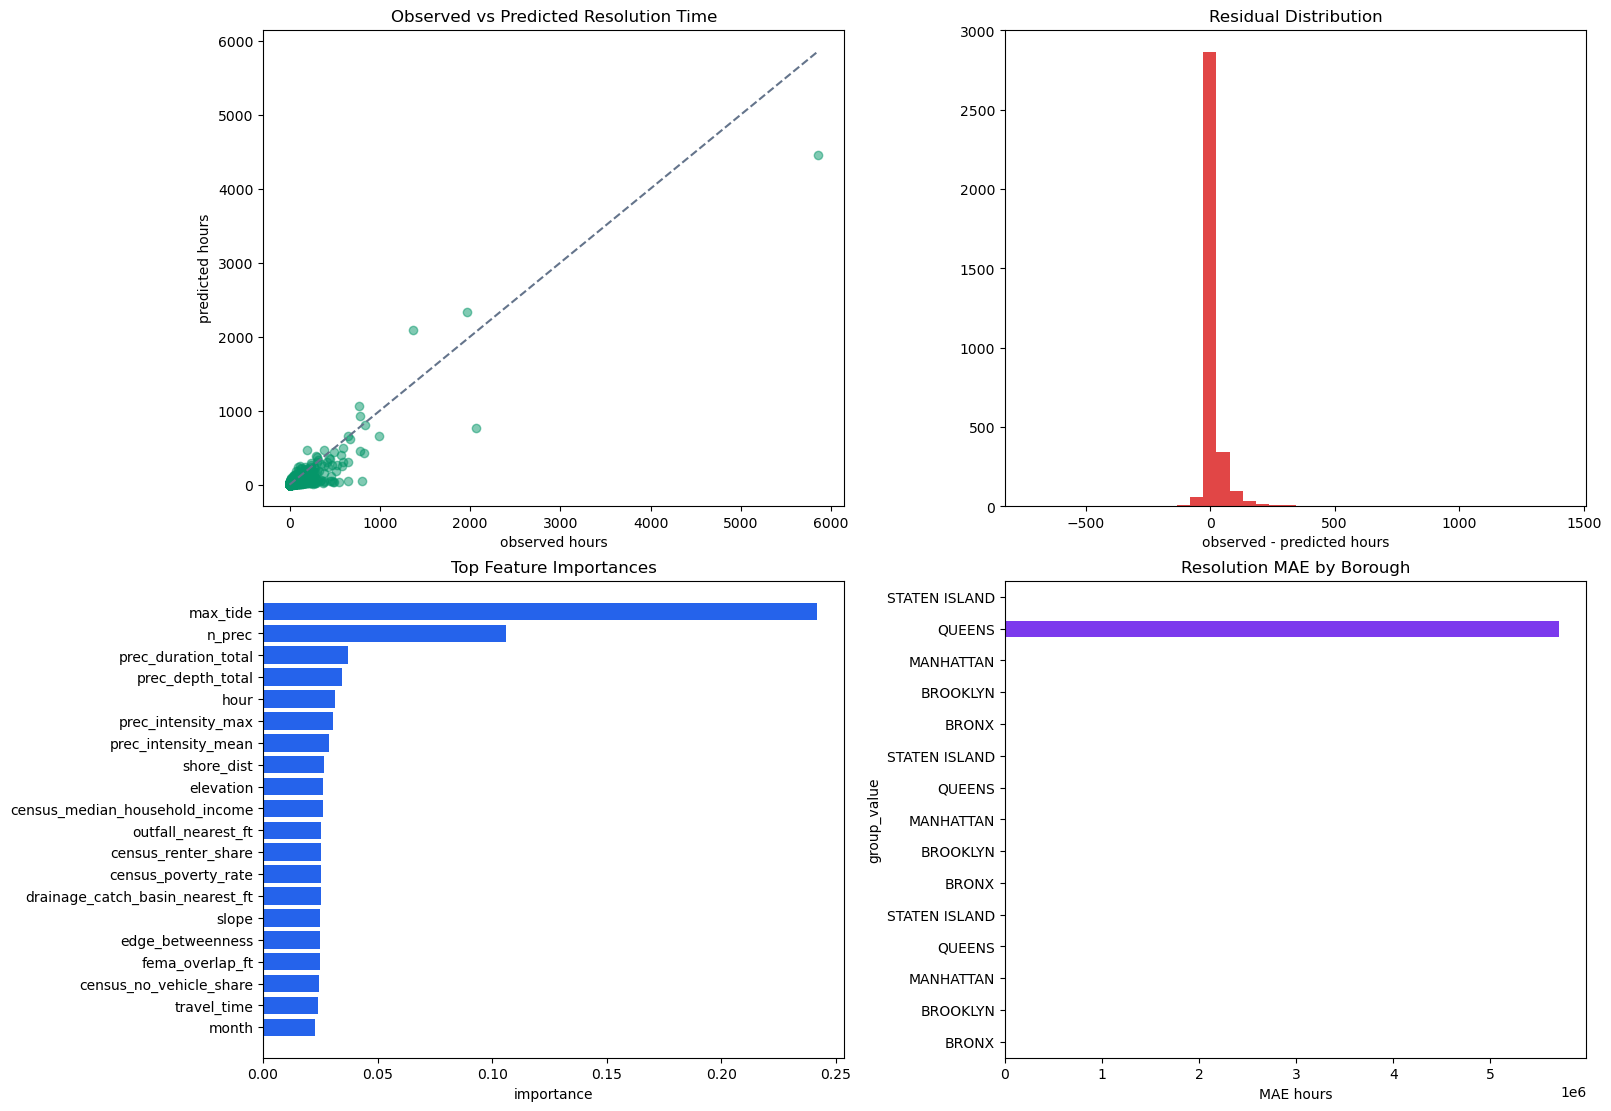

In [6]:
best_row = (
    results.query("status == 'ok'")
    .sort_values(["mae", "rmse"], ascending=[True, True], kind="stable")
    .iloc[0]
)
best_predictions = predictions[
    (predictions["model_name"] == best_row["model_name"])
    & (predictions["split_strategy"] == best_row["split_strategy"])
    & (predictions["set_name"] == "test")
].copy()
best_predictions["residual"] = best_predictions["y_true"] - best_predictions["y_pred"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
axes[0, 0].scatter(best_predictions["y_true"], best_predictions["y_pred"], alpha=0.5, color="#059669")
axes[0, 0].plot(
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    [best_predictions["y_true"].min(), best_predictions["y_true"].max()],
    linestyle="--",
    color="#64748B",
)
axes[0, 0].set_title("Observed vs Predicted Resolution Time")
axes[0, 0].set_xlabel("observed hours")
axes[0, 0].set_ylabel("predicted hours")

axes[0, 1].hist(pd.to_numeric(best_predictions["residual"], errors="coerce").dropna(), bins=40, color="#DC2626", alpha=0.85)
axes[0, 1].set_title("Residual Distribution")
axes[0, 1].set_xlabel("observed - predicted hours")

top_features = feature_importance.head(20).sort_values("importance", kind="stable")
axes[1, 0].barh(top_features["feature"], top_features["importance"], color="#2563EB")
axes[1, 0].set_title("Top Feature Importances")
axes[1, 0].set_xlabel("importance")

bias.query("bias_dimension == 'borough'").plot.barh(x="group_value", y="mae", ax=axes[1, 1], color="#7C3AED", legend=False)
axes[1, 1].set_title("Resolution MAE by Borough")
axes[1, 1].set_xlabel("MAE hours")
plt.show()